             開始 RLC 參數反求訓練              


100%|██████████| 8000/8000 [01:43<00:00, 76.96it/s, Loss=0.0362, R=1.202, L=1.499, C=0.300]



                     RLC 反求參數總結報告                      
參數類型       | 真實值 (True)   | 預估值 (Est.)   | 相對誤差 (%)  
------------------------------------------------------------
電阻 R         | 1.20           | 1.2019         | 0.16      %
電感 L         | 1.50           | 1.4990         | 0.07      %
電容 C         | 0.30           | 0.3001         | 0.02      %


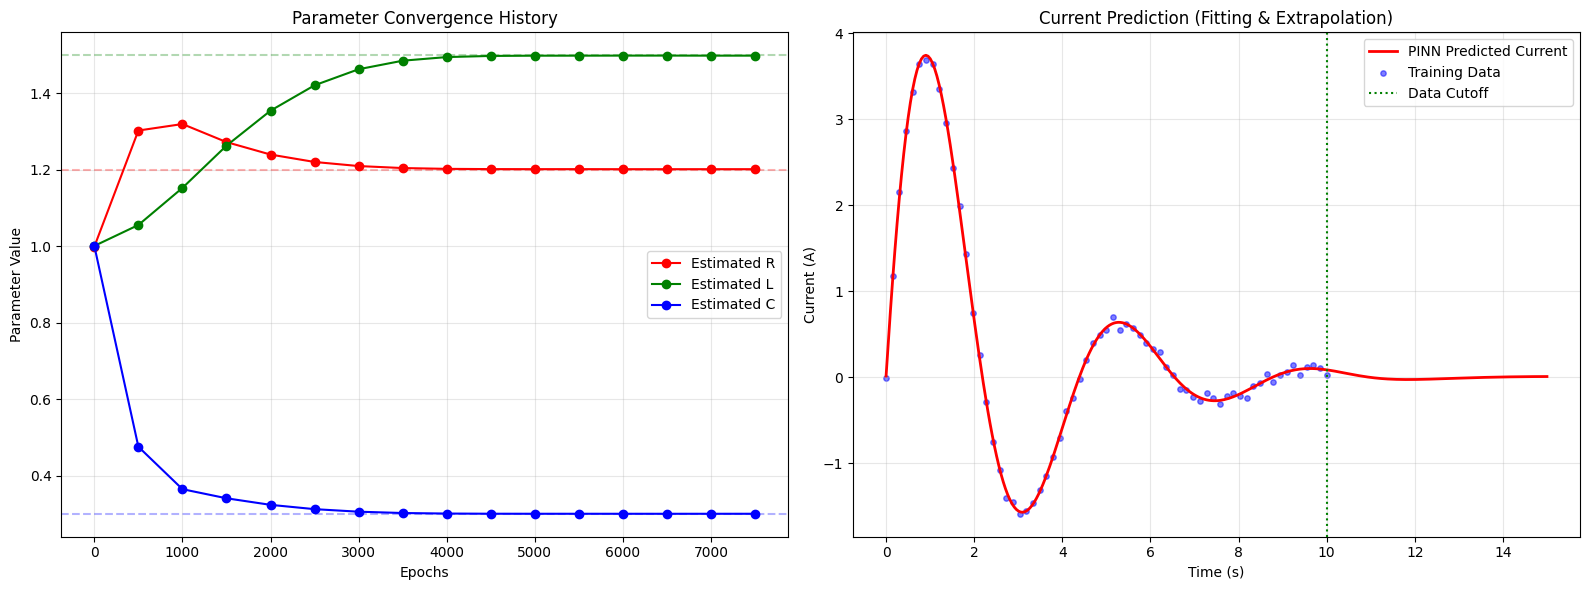

In [19]:
# -*- coding: utf-8 -*-
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomNormal
import math
from tqdm import trange

# ==========================================
# 1. 真實參數與環境設定 (假裝我們不知道 R, L, C)
# ==========================================
R_true = 1.2    # 電阻真實值 (kohm)
L_true = 1.5    # 電感真實值 (H)
C_true = 0.3    # 電容真實值 (F)
VC_0 = 12.0     # 初始電壓 (V)

# 時間參數
t_total = 15.0  # 總模擬時間
t_cutoff = 10.0 # 用於擬合的觀測資料區間

# 訓練參數
epochs = 8000
learning_rate = 0.001

# ==========================================
# 2. 定義待求參數 (可訓練變數)
# ==========================================
R_est = tf.Variable(1.0, trainable=True, dtype=tf.float32)
L_est = tf.Variable(1.0, trainable=True, dtype=tf.float32)
C_est = tf.Variable(1.0, trainable=True, dtype=tf.float32)

# ==========================================
# 3. 數據準備
# ==========================================
t_obs_full = np.linspace(0, t_total, 100, dtype=np.float32).reshape(-1, 1)

alpha = R_true / (2 * L_true)
w0 = np.sqrt(1 / (L_true * C_true))
wd = np.sqrt(w0**2 - alpha**2)
i_true_full = (VC_0 / (L_true * wd)) * np.exp(-alpha * t_obs_full) * np.sin(wd * t_obs_full)
i_obs_full = (i_true_full + 0.05 * np.random.normal(size=t_obs_full.shape)).astype(np.float32)

mask = t_obs_full.flatten() <= t_cutoff
t_obs_train = t_obs_full[mask]
i_obs_train = i_obs_full[mask]

t_col = np.linspace(0, t_total, 300, dtype=np.float32).reshape(-1, 1)

t_init = np.array([[0.0]], dtype=np.float32)
i_init = np.array([[0.0]], dtype=np.float32)
v_init_val = np.array([[VC_0]], dtype=np.float32)

# ==========================================
# 4. 神經網路架構
# ==========================================
weight_init = RandomNormal()
input_layer = tf.keras.Input(shape=(1,))
x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init)(input_layer)
x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init)(x)
x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init)(x)
output_layer = layers.Dense(1, activation='linear', kernel_initializer=weight_init)(x)
model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=learning_rate)

# ==========================================
# 5. 損失函數 (與參數更新邏輯)
# ==========================================
@tf.function
def step(t_col, t_init, i_init, v_init_val, t_obs, i_obs):
    with tf.GradientTape() as tape_w:
        pred_obs = model(t_obs)
        loss_data = tf.reduce_mean(tf.square(pred_obs - i_obs))

        pred_0 = model(t_init)
        loss_init_i = tf.reduce_mean(tf.square(pred_0 - i_init))

        with tf.GradientTape() as tape_v:
            tape_v.watch(t_init)
            pred_v = model(t_init)
        didt_0 = tape_v.gradient(pred_v, t_init)
        loss_init_v = tf.reduce_mean(tf.square(didt_0 * L_est - v_init_val))

        with tf.GradientTape() as tape_t2:
            tape_t2.watch(t_col)
            with tf.GradientTape() as tape_t1:
                tape_t1.watch(t_col)
                pred_i = model(t_col)
            didt = tape_t1.gradient(pred_i, t_col)
        d2idt2 = tape_t2.gradient(didt, t_col)

        residual = L_est * d2idt2 + R_est * didt + (1.0 / C_est) * pred_i
        loss_physics = tf.reduce_mean(tf.square(residual))

        total_loss = 20.0 * loss_data + 1.0 * loss_init_i + 1.0 * loss_init_v + 1.0 * loss_physics

    trainable_vars = model.trainable_variables + [R_est, L_est, C_est]
    grads = tape_w.gradient(total_loss, trainable_vars)
    optimizer.apply_gradients(zip(grads, trainable_vars))
    return total_loss

# ==========================================
# 6. 訓練執行 (整合動態進度條)
# ==========================================
history_RLC = []
print("="*50)
print(f"{'開始 RLC 參數反求訓練':^40}")
print("="*50)

# 使用 with 語句管理 trange，以便動態更新描述
with trange(epochs) as pbar:
    for epoch in pbar:
        loss = step(t_col, t_init, i_init, v_init_val, t_obs_train, i_obs_train)

        # 獲取當前參數數值
        r_val, l_val, c_val = R_est.numpy(), L_est.numpy(), C_est.numpy()

        # 每一步都更新進度條右側的數值顯示
        pbar.set_postfix({
            "Loss": f"{loss.numpy():.4f}",
            "R": f"{r_val:.3f}",
            "L": f"{l_val:.3f}",
            "C": f"{c_val:.3f}"
        })

        # 每 500 次將參數記錄到 history 中以便最後繪圖
        if epoch % 500 == 0:
            history_RLC.append([r_val, l_val, c_val])

# ==========================================
# 7. 最終報告與視覺化
# ==========================================
def print_report(r_t, l_t, c_t, r_e, l_e, c_e):
    err_r = abs(r_e - r_t) / r_t * 100
    err_l = abs(l_e - l_t) / l_t * 100
    err_c = abs(c_e - c_t) / c_t * 100

    print("\n" + "="*60)
    print(f"{'RLC 反求參數總結報告':^55}")
    print("="*60)
    print(f"{'參數類型':<10} | {'真實值 (True)':<12} | {'預估值 (Est.)':<12} | {'相對誤差 (%)':<10}")
    print("-" * 60)
    print(f"{'電阻 R':<12} | {r_t:<14.2f} | {r_e:<14.4f} | {err_r:<10.2f}%")
    print(f"{'電感 L':<12} | {l_t:<14.2f} | {l_e:<14.4f} | {err_l:<10.2f}%")
    print(f"{'電容 C':<12} | {c_t:<14.2f} | {c_e:<14.4f} | {err_c:<10.2f}%")
    print("="*60)

print_report(R_true, L_true, C_true, R_est.numpy(), L_est.numpy(), C_est.numpy())

# --- 繪圖區 ---
history_RLC = np.array(history_RLC)
epochs_x = np.arange(0, len(history_RLC) * 500, 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. 參數收斂歷史圖
ax1.plot(epochs_x, history_RLC[:, 0], 'r-o', label='Estimated R')
ax1.axhline(y=R_true, color='r', linestyle='--', alpha=0.3)
ax1.plot(epochs_x, history_RLC[:, 1], 'g-o', label='Estimated L')
ax1.axhline(y=L_true, color='g', linestyle='--', alpha=0.3)
ax1.plot(epochs_x, history_RLC[:, 2], 'b-o', label='Estimated C')
ax1.axhline(y=C_true, color='b', linestyle='--', alpha=0.3)
ax1.set_title("Parameter Convergence History")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Parameter Value")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. 最終電流擬合預測圖
t_test = np.linspace(0, t_total, 300).reshape(-1, 1)
i_pred = model(t_test).numpy()
ax2.plot(t_test, i_pred, 'r-', linewidth=2, label='PINN Predicted Current')
ax2.scatter(t_obs_train, i_obs_train, s=15, color='blue', alpha=0.5, label='Training Data')
ax2.axvline(x=t_cutoff, color='green', linestyle=':', label='Data Cutoff')
ax2.set_title("Current Prediction (Fitting & Extrapolation)")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Current (A)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()